### Exercise: Load and Preview the California Housing Dataset

**Instructions:**

1. Read the dataset file `california_housing_train.csv` using the `pandas` library.
2. Print the first 5 rows of the dataset.

**Expected Output:**

The first 5 rows of the dataset should be displayed, showing columns like `longitude`, `latitude`, `housing_median_age`, etc.


In [34]:
import pandas as pd

# Load the dataset
df = pd.read_csv('california_housing_train.csv')

# Print the first 5 rows
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### Exercise: Separate Features (X) and Target (y)

**Instructions:**

1. Use the California housing dataset loaded in the previous step.
2. Define `X` as the feature matrix by removing the target column.
3. Define `y` as the target vector. The target column is usually named `median_house_value`.

**Expected Output:**

- `X` should be a DataFrame containing all columns **except** `median_house_value`.
- `y` should be a Series containing only the `median_house_value` column.


In [35]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]



```
# This is formatted as code
```

Print the first 5 rows of the x.

In [36]:
display(X.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


### Exercise: Print the Shape of Feature Matrix X

**Instructions:**

1. Using the feature matrix `X` defined earlier, print its shape (number of rows and columns).

**Expected Output:**

- The output should display a tuple showing the dimensions of `X`, for example `(17000, 8)` indicating 17,000 rows and 8 columns.


In [37]:
X.shape

(17000, 8)

### Exercise: Split the Dataset into Training and Test Sets

**Instructions:**

1. Split the dataset into training and test sets.
2. Use 20% of the data as the test set.
3. Use `train_test_split` from `sklearn.model_selection` for splitting.

**Expected Output:**

- You should have four variables: `X_train`, `X_test`, `y_train`, and `y_test`.
- The test set should contain approximately 20% of the samples.


In [38]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13600, 8)
X_test shape: (3400, 8)
y_train shape: (13600,)
y_test shape: (3400,)


### Exercise: Define the Device for PyTorch

**Instructions:**

1. Import `torch` library.
2. Define a variable `device` that uses GPU if available, otherwise CPU.
3. Print the selected device.

**Expected Output:**

- The output should show either `cuda` (if GPU is available) or `cpu`.



In [39]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Exercise: Convert Training Data to PyTorch Tensors (with Correct Shape)

**Instructions:**

1. Convert the training feature matrix `X_train` and the target vector `y_train` to PyTorch tensors.
2. Ensure that `X_train_tensor` has data type `float32` and shape `(n_samples, n_features)`.
3. Ensure that `y_train_tensor` has shape `(n_samples, 1)` (i.e., two-dimensional).
4. Move both tensors to the appropriate `device` (CPU or GPU).

**Expected Output:**

- `X_train_tensor`: a 2D tensor of shape `[number_of_samples, number_of_features]`.
- `y_train_tensor`: a 2D tensor of shape `[number_of_samples, 1]`.


In [40]:
# Convert training data to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)

# Print shapes to verify
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

X_train_tensor shape: torch.Size([13600, 8])
y_train_tensor shape: torch.Size([13600, 1])


### Exercise: Build a Neural Network Model with 3 Layers

**Instructions:**

1. Build a PyTorch neural network model.
2. The architecture should include 3 layers:
   - First layer: 5 neurons with ReLU activation
   - Second layer: 3 neurons with ReLU activation
   - Final layer: 1 neuron (no activation function)
3. Do **not** apply any activation function to the output layer.

**Expected Output:**

- A model object containing 3 layers.
- The output of the model should be a single continuous value suitable for regression.


In [41]:
import torch.nn as nn
from torch import optim

# Define the neural network model using a class
class ManualRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(in_features = input_size , out_features = 5)
        self.relu_1 = nn.ReLU()
        self.fc2 = nn.Linear(5, 3)
        self.relu_2 = nn.ReLU()
        self.fc3= nn.Linear(3, 1)

    def forward(self, x):
        x = self.relu_1(self.fc1(x))
        x = self.relu_2(self.fc2(x))
        x = self.fc3(x) # No activation on the output layer
        return x

# Instantiate the model and move to device
model = ManualRegression(X_train_tensor.shape[1]).to(device)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001) # Using SGD with a learning rate

print(model)

ManualRegression(
  (fc1): Linear(in_features=8, out_features=5, bias=True)
  (relu_1): ReLU()
  (fc2): Linear(in_features=5, out_features=3, bias=True)
  (relu_2): ReLU()
  (fc3): Linear(in_features=3, out_features=1, bias=True)
)


### Exercise: Implement the Training Loop and Train the Model

**Instructions:**

1. Write a training loop to train the model for **500 epochs**.
2. Use **Mean Squared Error (MSE)** as the loss function.
3. Use an optimizer such as **SGD**.
4. In each epoch:
   - Perform a forward pass.
   - Compute the loss.
   - Perform a backward pass.
   - Update the model parameters.
5. Print the loss every 50 epochs to monitor training progress.

**Expected Output:**

- The model should train for 500 epochs.
- You should see printed loss values at regular intervals (e.g., every 50 epochs).
- The loss should generally decrease over time if the model is learning properly.


In [52]:
# Training loop
n_epochs = 500
losses = [] # To store loss values for plotting later

# Assuming model, criterion, and optimizer are already defined and moved to device

for epoch in range(n_epochs):
    # Forward pass
    outputs = model(X_train_tensor) # Use normalized training data
    loss = criterion(outputs, y_train_tensor) # Use normalized target data

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch: {epoch+1} train_loss = {loss.item()}')
    losses.append(loss.item())

Epoch: 50 train_loss = 4.7034061814409236e+27
Epoch: 100 train_loss = 3.8500530121893006e+27
Epoch: 150 train_loss = 3.151526169853421e+27
Epoch: 200 train_loss = 2.579736428297366e+27
Epoch: 250 train_loss = 2.1116849773058447e+27
Epoch: 300 train_loss = 1.728555990349721e+27
Epoch: 350 train_loss = 1.4149387622819123e+27
Epoch: 400 train_loss = 1.1582213279662e+27
Epoch: 450 train_loss = 9.480819224366044e+26
Epoch: 500 train_loss = 7.76068321345528e+26


### Exercise: Analyze the Training Behavior

**Instructions:**

After training the model for 500 epochs, observe the printed loss values over time.

You are expected to see a decreasing trend in the loss, indicating that the model is learning and updating its parameters correctly.

However, you might notice that:

- The loss is **not decreasing significantly**, or
- The loss remains **almost constant**, or
- The loss shows **unexpected fluctuations**.

This suggests that **learning may not be happening as expected**, even though the training loop and model definition seem correct.

**Question:**

What could be the reasons for the model not learning properly?

- The code logic appears to be correct.
- The model runs without errors.
- The loss function and optimizer are standard.

**Hint:** Think about the nature and scale of the input data. Neural networks are sensitive to the scale of input features. You may consider whether data **normalization or standardization** is necessary before feeding inputs into the model.

Discuss what might be going wrong and how you would investigate or fix it.


In [43]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming X_train_tensor is your input data (PyTorch tensor)
# Convert to numpy for sklearn preprocessing
X_train_np = X_train_tensor.cpu().numpy()  # Move to CPU and convert to numpy if it's a GPU tensor

# Initialize and fit the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)  # Normalizes to mean=0, std=1

# Check mean and std (should be ~0 and ~1)
print("Mean after scaling:", X_train_scaled.mean(axis=0))  # Should be close to 0
print("Std after scaling:", X_train_scaled.std(axis=0))    # Should be close to 1

# Convert back to PyTorch tensor and move to device (e.g., GPU)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)

Mean after scaling: [-1.3463637e-08 -1.3463637e-08 -2.2439395e-09 -7.8537887e-09
 -4.7683715e-09  7.0123112e-09 -2.8049243e-10  6.0305876e-09]
Std after scaling: [1.         1.         1.         1.         1.         1.
 1.         0.99999994]


### Exercise: Manually Normalize Input Features and Target (Without sklearn)

**Instructions:**

In regression problems, it's important to normalize both the **input features (`X`)** and the **target (`y`)** to improve the stability and efficiency of training.

You will perform **standard normalization** (zero mean and unit variance) **manually**, without using any external library such as `sklearn`.

---

#### 🔹 Normalization Formula:

For each column (feature or target), apply:

$$
x_{\text{normalized}} = \frac{x - \mu}{\sigma}
$$

where:

- \( x \): original value  
- \( \mu \): mean of the column (computed from `X_train` or `y_train`)  
- \( \sigma \): standard deviation of the column (computed from `X_train` or `y_train`)  

---

#### 🔹 Your Tasks:

1. Compute the mean and standard deviation of each feature column in `X_train`.
2. Normalize `X_train` using these values.
3. Normalize `X_test` using the **same** mean and std from `X_train`.
4. Compute the mean and std of `y_train`, then normalize it.
5. Apply the same transformation to `y_test`.
6. After normalization, convert all the data to PyTorch tensors and move them to the appropriate `device`.

---

#### ⚠️ Notes:

- Do **not** use `sklearn.preprocessing.StandardScaler` or any similar library.
- Normalization must be done **before converting the data to PyTorch tensors**.
- Keep track of the mean and std values for `y` — they will be needed later to **de-normalize predictions** (e.g., for evaluation or visualization).
- Without proper normalization, the model may fail to learn effectively, especially if feature scales differ significantly.

---

**Expected Output:**

- Each column in `X_train` should have a mean close to 0 and standard deviation close to 1.
- The same applies to `y_train`.
- `X_test` and `y_test` should be transformed using `X_train` and `y_train` statistics.
- Model training loss should now decrease more consistently compared to training without normalization.



In [49]:
import numpy as np
import torch

# 1. Convert DataFrames to NumPy arrays first (if they aren't already)
X_train = np.array(X_train) if not isinstance(X_train, np.ndarray) else X_train
X_test = np.array(X_test) if not isinstance(X_test, np.ndarray) else X_test
y_train = np.array(y_train) if not isinstance(y_train, np.ndarray) else y_train
y_test = np.array(y_test) if not isinstance(y_test, np.ndarray) else y_test

# 2. Compute statistics and normalize X
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1.0  # Prevent division by zero

X_train_normalized = (X_train - X_mean) / X_std
X_test_normalized = (X_test - X_mean) / X_std

# 3. Normalize y (reshape to 2D if needed)
y_train = y_train.reshape(-1, 1) if len(y_train.shape) == 1 else y_train
y_test = y_test.reshape(-1, 1) if len(y_test.shape) == 1 else y_test

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

y_train_normalized = (y_train - y_mean) / y_std
y_test_normalized = (y_test - y_mean) / y_std

# 4. Convert to tensors (now guaranteed to work)
X_train_tensor = torch.tensor(X_train_normalized, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_normalized, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_normalized, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_normalized, dtype=torch.float32).to(device)

### Exercise: Convert Normalized Data to Tensors, Train the Model, and Plot Loss

**Instructions:**

1. Convert the normalized `X_train`, `X_test`, `y_train`, and `y_test` data to PyTorch tensors.
2. Move the tensors to the appropriate device (CPU or GPU).
3. Train the model using the normalized training data.
4. During training, record the loss value for each epoch.
5. After training, plot the training loss curve over all epochs to visualize the learning progress.
6. Analyze the plot to confirm that the loss decreases smoothly over time, indicating successful training.

**Expected Output:**

- Tensors for all datasets on the correct device.
- A training loss plot showing a generally decreasing trend.
- Confirmation that normalization helped stabilize and improve training.


In [51]:
# Convert normalized NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_normalized, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_normalized, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_normalized, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_normalized, dtype=torch.float32).to(device)

# Print shapes to verify
print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([13600, 8])
X_test_tensor shape: torch.Size([3400, 8])
y_train_tensor shape: torch.Size([13600, 1])
y_test_tensor shape: torch.Size([3400, 1])


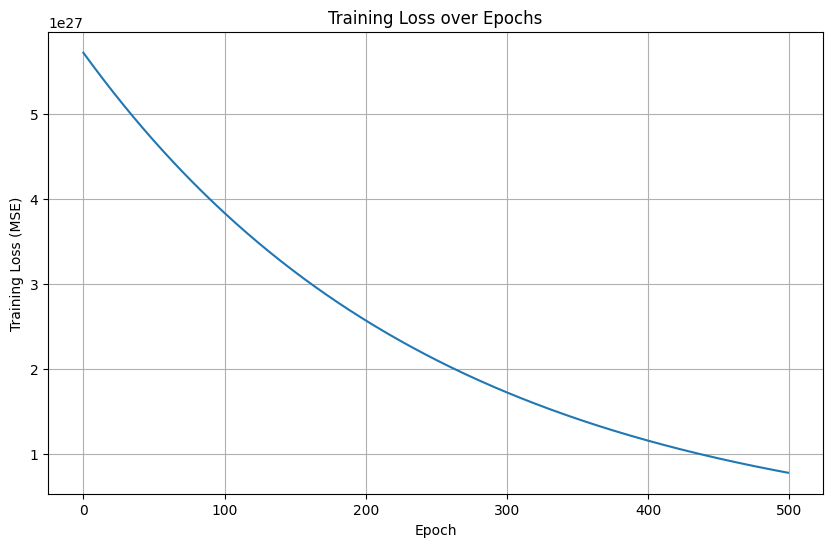

In [55]:
import matplotlib.pyplot as plt

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(n_epochs), losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

### Exercise: Increase Model Complexity and Experiment with Learning Rates

**Instructions:**

1. Modify your neural network model to make it more complex by:
   - Increasing the number of layers (e.g., 4 or 5 layers).
   - Increasing the number of neurons in each layer (e.g., 64, 32, 16, 8, 1).
   - Use ReLU activation in all layers except the last.
2. Train the model with **different learning rates** (e.g., 0.01, 0.001, 0.0001).
3. For each learning rate:
   - Train the model for the same number of epochs.
   - Record the training loss over epochs.
4. Compare and analyze the results to determine how learning rate affects the training process and final performance.
5. Optionally, plot the training loss curves for different learning rates on the same graph for better comparison.

**Expected Output:**

- Multiple trained models with varying learning rates.
- Training loss plots showing how different learning rates impact convergence speed and stability.
- An analysis explaining which learning rate works best and why.



Training with learning rate: 0.01
Epoch: 100 train_loss = 0.9826704263687134
Epoch: 200 train_loss = 0.9476355314254761
Epoch: 300 train_loss = 0.7823030948638916
Epoch: 400 train_loss = 0.4536035656929016
Epoch: 500 train_loss = 0.3873428404331207

Training with learning rate: 0.001
Epoch: 100 train_loss = 1.0074188709259033
Epoch: 200 train_loss = 0.9994813799858093
Epoch: 300 train_loss = 0.9943957924842834
Epoch: 400 train_loss = 0.9908953905105591
Epoch: 500 train_loss = 0.9882534742355347

Training with learning rate: 0.0001
Epoch: 100 train_loss = 1.078979253768921
Epoch: 200 train_loss = 1.0755839347839355
Epoch: 300 train_loss = 1.0723106861114502
Epoch: 400 train_loss = 1.0691567659378052
Epoch: 500 train_loss = 1.0661216974258423


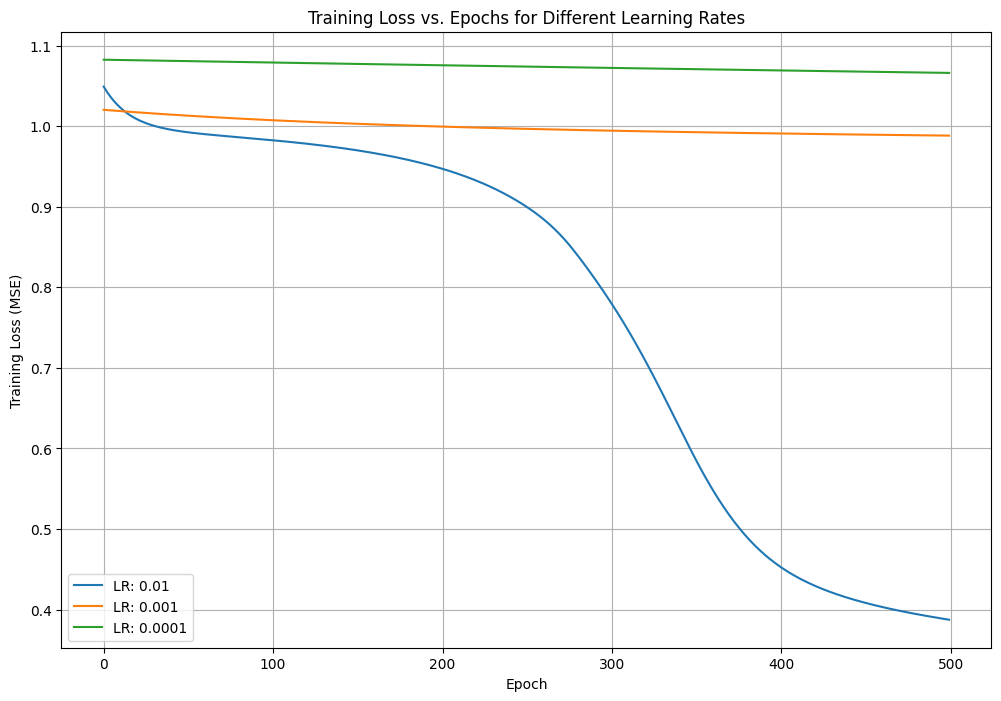

In [56]:
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

# Define a more complex neural network model
class ComplexRegressionModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(in_features=input_size, out_features=64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 16)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(16, 8)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(8, 1) # Output layer

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        x = self.fc5(x) # No activation on the output layer
        return x

# Define learning rates to experiment with
learning_rates = [0.01, 0.001, 0.0001]
n_epochs = 500
all_losses = {} # Dictionary to store losses for each learning rate

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    # Instantiate the complex model and move to device
    model_complex = ComplexRegressionModel(X_train_tensor.shape[1]).to(device)

    # Define the loss function and optimizer for the complex model
    criterion_complex = nn.MSELoss()
    optimizer_complex = optim.SGD(model_complex.parameters(), lr=lr)

    losses_lr = [] # To store loss values for the current learning rate

    for epoch in range(n_epochs):
        # Forward pass
        outputs = model_complex(X_train_tensor)
        loss = criterion_complex(outputs, y_train_tensor)

        # Backward and optimize
        optimizer_complex.zero_grad()
        loss.backward()
        optimizer_complex.step()

        # Print loss every 100 epochs (or adjust as needed)
        if (epoch + 1) % 100 == 0:
            print(f'Epoch: {epoch+1} train_loss = {loss.item()}')
        losses_lr.append(loss.item())

    all_losses[lr] = losses_lr # Store losses for this learning rate

# Plot the training loss for each learning rate
plt.figure(figsize=(12, 8))
for lr, losses in all_losses.items():
    plt.plot(range(n_epochs), losses, label=f'LR: {lr}')

plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss vs. Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

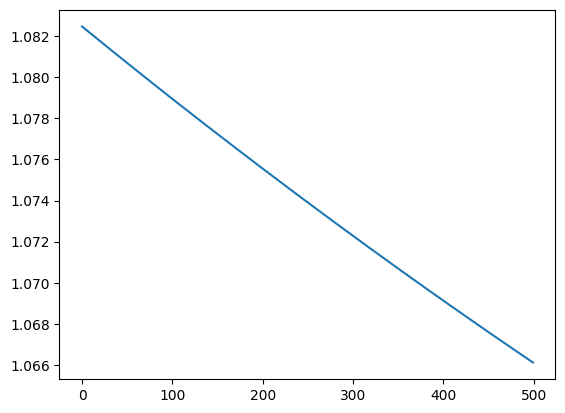

In [57]:
import matplotlib.pyplot as plt
plt.plot(range(n_epochs), losses)
plt.show()

Based on the hint and the observed behavior, it is highly likely that the issue is related to the scale of your input data. Neural networks are very sensitive to the range of values in the input features. When features have vastly different scales, the optimization process can become unstable, leading to issues like the loss not decreasing or showing unexpected fluctuations.

Here's a more detailed explanation:

*   **Gradient Descent Issues:** Without normalization, the gradients for parameters associated with features having larger scales can be much larger than those for features with smaller scales. This can cause the optimizer (like SGD) to take very large steps in one direction and very small steps in another, making it difficult to converge to the optimal solution. The optimizer might oscillate or get stuck in local minima.
*   **Activation Function Saturation:** Some activation functions (like sigmoid or tanh) can saturate for very large or small input values. If your features are not normalized, the inputs to these activation functions in the hidden layers might fall into the saturation regions, where the gradients are close to zero. This effectively stops the learning process for those neurons.
*   **Learning Rate Sensitivity:** The optimal learning rate for an unnormalized dataset can be very small, making training slow. If you use a larger learning rate, it might cause the optimizer to overshoot the minimum and diverge.

**How to investigate and fix it:**

1.  **Inspect Data Scales:** Calculate and print the mean and standard deviation (or min/max) of each feature in your dataset. You'll likely see significant differences in scale.
2.  **Normalize/Standardize Data:** Apply a normalization or standardization technique to your input features (X) and potentially your target variable (y) before feeding them into the neural network. Standardization (subtracting the mean and dividing by the standard deviation) is a common approach for neural networks and is suggested in the next exercise.
3.  **Re-train the Model:** After normalizing the data, retrain your model using the same architecture and hyperparameters. You should observe a much more stable and decreasing loss curve.
4.  **Experiment with Learning Rate:** Once the data is normalized, you can experiment with different learning rates again to find the optimal one for faster convergence.

The next exercise specifically guides you through manually normalizing the data, which is the crucial step to address this issue.